# 《微信红包“手气最佳接龙”的机制分析与最优参与策略研究》

## 一、摘要

## 二、关键词

## 三、引言

## 四、研究过程

### （一）微信红包机制分析

#### 1、数据统计

##### 1.1 数据收集

我们于2025年1月16日，在8人微信群中进行数据收集。我们共发40元红包，8人抢，一共五百个，并按照抢红包的顺序进行数据统计，得到原始数据：envelopes.csv（附件一）

##### 1.2 数据处理与可视化

我们对所收集到的数据进行处理，得到以下图以及数据：

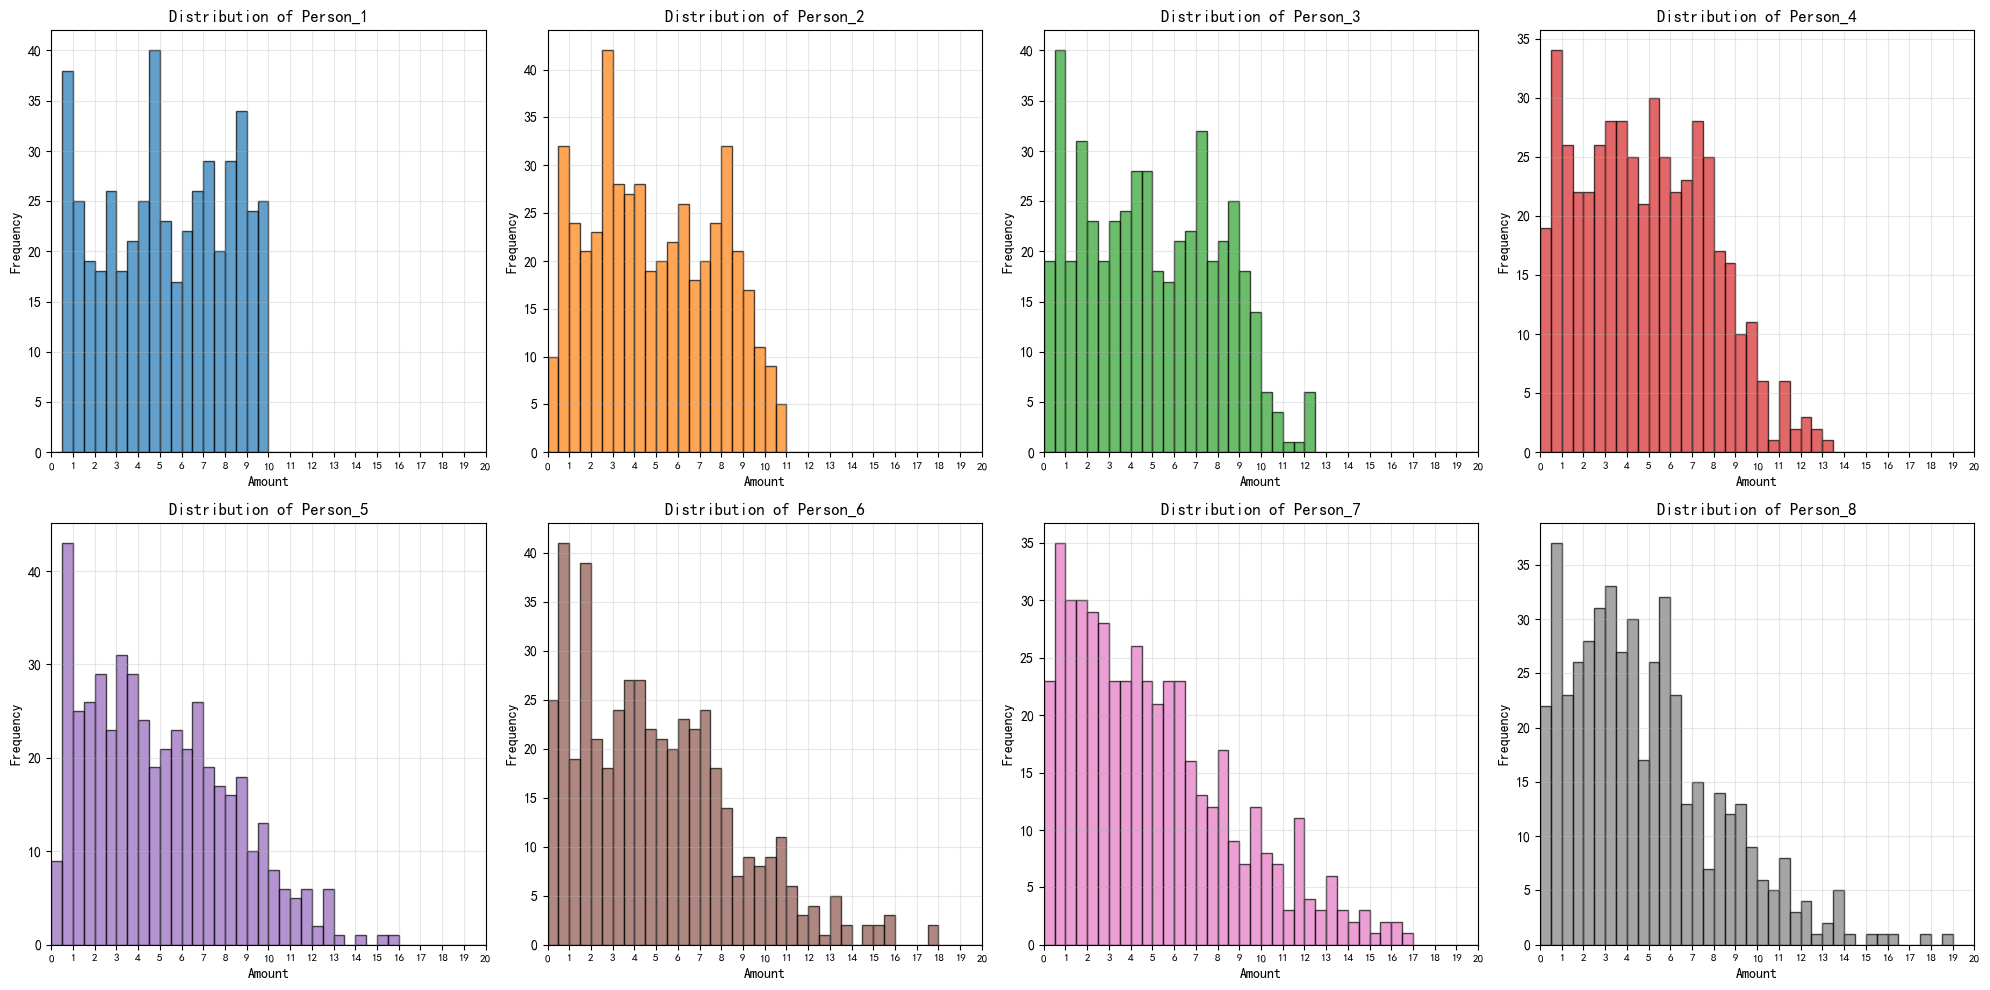

C:\Users\21272\AppData\Local\Temp\ipykernel_35936\3642281019.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels)


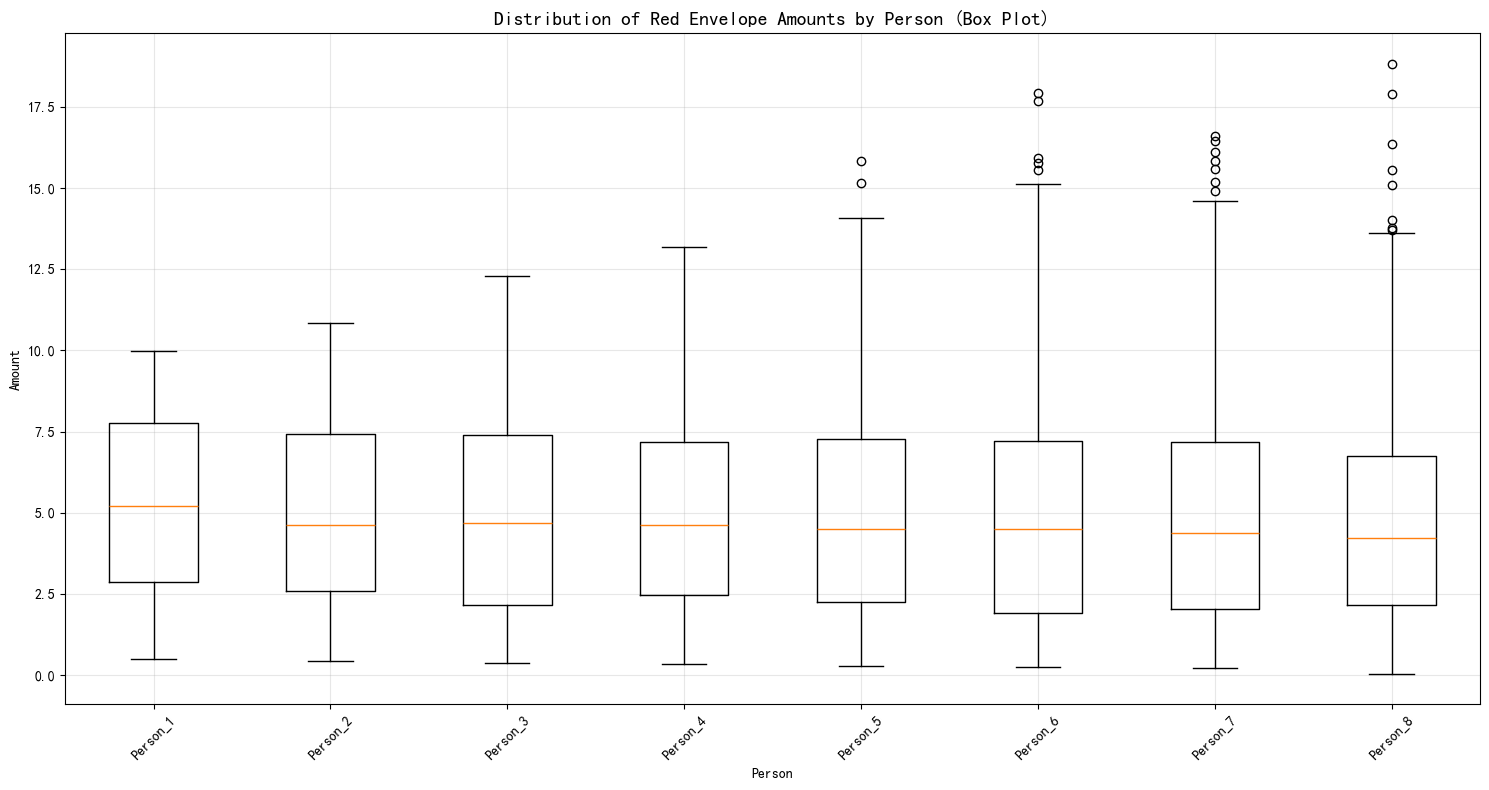

Number of trials: 480
Number of people: 8
Total amount per trial: 40.0

Summary statistics:
          Person_1     Person_2     Person_3     Person_4     Person_5  \
count   480.000000   480.000000   480.000000   480.000000   480.000000   
mean     10.572083     9.834229     9.926875     9.741167    10.020271   
std     115.753324   107.556268   108.787134   106.559084   109.799721   
min       0.500000     0.440000     0.380000     0.360000     0.300000   
25%       2.870000     2.587500     2.165000     2.467500     2.247500   
50%       5.225000     4.670000     4.710000     4.625000     4.515000   
75%       7.790000     7.457500     7.402500     7.215000     7.285000   
max    2540.570000  2360.540000  2387.420000  2338.570000  2409.550000   

          Person_6     Person_7     Person_8  
count   480.000000   480.000000   480.000000  
mean     10.038083    10.074083     9.709875  
std     109.843055   110.214872   106.400205  
min       0.260000     0.230000     0.040000  
25%   

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取CSV数据
path = "最大似然估计和KS检验\\均匀分布估计\\envelopes.csv"
raw = pd.read_csv(path)

# 获取数据（跳过表头行）
data = raw.iloc[1:].reset_index(drop=True)

# 获取参数
number = data.shape[0]  # 样本数量
people = data.shape[1] - 1  # 参与者数量（去掉第一列Trial）
money = data.iloc[:, 1:].sum(axis=1).iloc[0]  # 每次试验的总金额

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 为数据添加列名
pos_cols = [f"Person_{i+1}" for i in range(people)]
data.columns = ['Trial'] + pos_cols

# 创建图形，8个子图
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

# 为每个参与者绘制频数直方图
for i, col in enumerate(pos_cols):
    # 只显示0到10之间的数据，并设置bins
    filtered_data = data[col].astype(float)[data[col].astype(float) <= 20]
    n, bins, patches = axes[i].hist(filtered_data, bins=np.arange(0, 20.1, 0.5), alpha=0.7, color=f'C{i}', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('Amount')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)
    
    # 设置横坐标范围和刻度
    axes[i].set_xlim(0, 20)
    axes[i].set_xticks(np.arange(0, 20.1, 1))  # 每1个单位一个刻度
    axes[i].tick_params(axis='x', labelsize=8)  # 减小字体大小以适应更多标签

plt.tight_layout()
plt.show()

# 创建箱型图
plt.figure(figsize=(15, 8))

# 提取数据并转换为浮点型
box_data = []
labels = []
for col in pos_cols:
    values = data[col].astype(float)
    # 过滤掉异常值（可选，这里设定上限为20）
    filtered_values = values[values <= 20]
    box_data.append(filtered_values)
    labels.append(col)

# 绘制箱型图
plt.boxplot(box_data, labels=labels)
plt.title('Distribution of Red Envelope Amounts by Person (Box Plot)', fontsize=14)
plt.xlabel('Person')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 打印基本信息
print(f"Number of trials: {number}")
print(f"Number of people: {people}")
print(f"Total amount per trial: {money}")
print("\nSummary statistics:")
print(data[pos_cols].describe())

##### 1.3 数据分析

从采集到的数据中我们不难得到一下结论：
1. 8个人所抢到单个红包的平均金额相近，约等于单个红包的总金额/人数（$40*2/8=10$）。
其中最大误差发生在第一位的。根据对于原始数据的进一步分析，我们发现，第一位所抢到的金额没有小于0.5元的，且出现抢到0.5元的概率远远大于其他金额，因此我们怀疑微信存在最小金额保底机制，具体保底金额为红包金额的10%。由于金额较小，对于结果的误差影响小，因此在接下来的研究过程中忽略最小金额保底机制。

2. 8个人所抢到金额的方差差距较大，整体满足先减小后增大的趋势。不过由于数据样本不足，趋势不明显且可能存在误差，因此此结论有待进一步研究。


#### 2. 模型建立

##### 2.1 模型猜测一：均匀分布

##### 2.1.1 模型描述

处于对于抢红包公平性以及机制简单性的考虑，我们首先考虑使用均匀分布进行建模。

##### 2.1.2 数据拟合
如果假设红包金额服从均匀分布，则其概率密度函数为：

$$ f(x|a,b) = \begin{cases} \frac{1}{b-a} & \text{if } a \leq x \leq b \ 0 & \text{otherwise} \end{cases} $$

其中：

- $a$ 是分布的下界（最低红包金额）
- $b$ 是分布的上界（最高红包金额）






[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


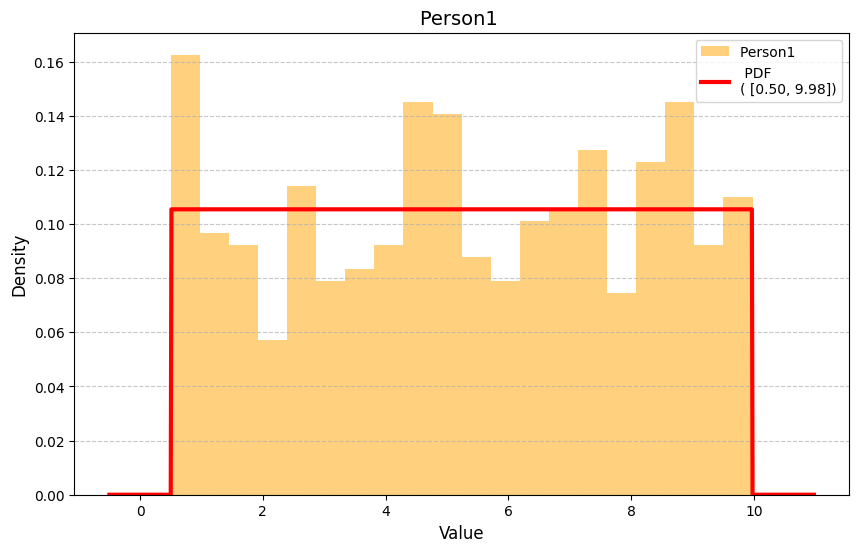

拟合结果：
最小值 (a): 0.5000
最大值 (b): 9.9800
区间长度 (b-a): 9.4800


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!python -m pip install scipy
from scipy.stats import uniform

df = pd.read_csv("最大似然估计和KS检验\\均匀分布估计\\envelopes.csv")



# 2. 数据清洗：剔除最后一行 "Total"
df_clean = df.iloc[:-1].copy()

# 确保 Person1 列为浮点数类型
person1_values = df_clean['Person1'].astype(float)

# 3. 使用均匀分布拟合数据
# uniform.fit 返回 (loc, scale)，其中 loc 是起点 a，scale 是区间长度 (b - a)
a_fit, scale_fit = uniform.fit(person1_values)
b_fit = a_fit + scale_fit

# 4. 绘图
plt.figure(figsize=(10, 6))

# 绘制直方图（density=True 保证纵坐标为概率密度）
plt.hist(person1_values, bins=20, density=True, alpha=0.5, color='orange', label='Person1 ')

# 生成拟合的 PDF 曲线
x = np.linspace(a_fit - 1, b_fit + 1, 1000)
pdf = uniform.pdf(x, loc=a_fit, scale=scale_fit)
plt.plot(x, pdf, 'r-', lw=3, label=f' PDF\n( [{a_fit:.2f}, {b_fit:.2f}])')

# 设置图表细节
plt.title('Person1 ', fontsize=14)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 输出拟合参数
print(f"拟合结果：")
print(f"最小值 (a): {a_fit:.4f}")
print(f"最大值 (b): {b_fit:.4f}")
print(f"区间长度 (b-a): {scale_fit:.4f}")


最终的拟合结果可以表示为：

$$ X_1 \sim Uniform(0.5, 9.98) $$


##### 2.1.3 KS 检验

Executing Monte Carlo Simulation (5000 iterations)...


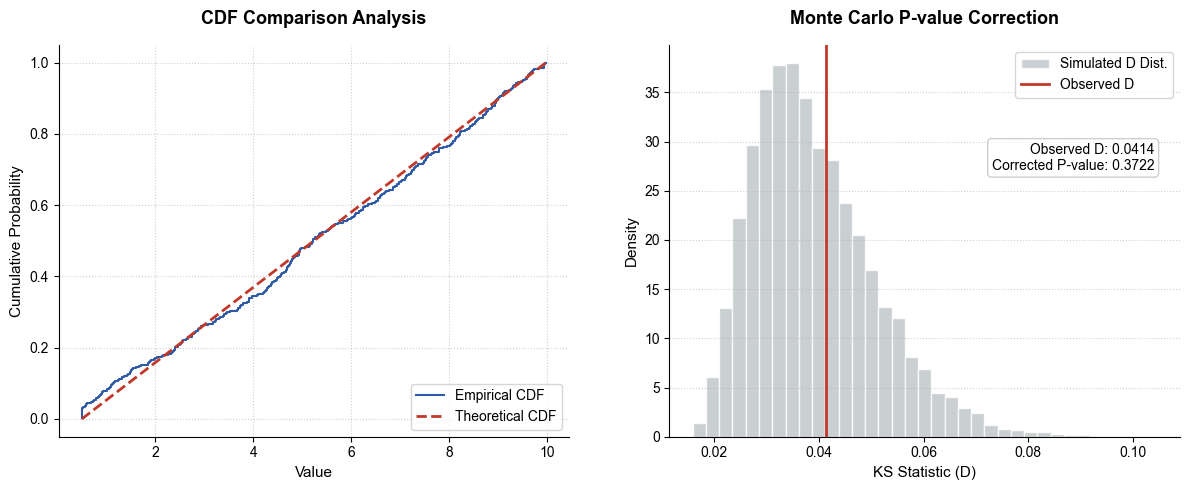

Fit Results: a=0.500, b=9.980
Corrected P-value: 0.3722


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, kstest
import io

# 1. 数据准备
# 假设 df 已经由之前的步骤读入
df_clean = df[df['Trial'] != 'Total'].copy()
person1_data = df_clean['Person1'].astype(float).values
n_samples = len(person1_data)

# 2. 参数估计与 KS 统计量计算
a_obs, scale_obs = uniform.fit(person1_data)
b_obs = a_obs + scale_obs
d_obs, _ = kstest(person1_data, 'uniform', args=(a_obs, scale_obs))

# 3. 蒙特卡洛模拟 (5000次)
n_sims = 5000
d_sims = np.zeros(n_sims)

print(f"Executing Monte Carlo Simulation ({n_sims} iterations)...")
for i in range(n_sims):
    sim_sample = uniform.rvs(loc=a_obs, scale=scale_obs, size=n_samples)
    a_sim, scale_sim = uniform.fit(sim_sample)
    d_sim, _ = kstest(sim_sample, 'uniform', args=(a_sim, scale_sim))
    d_sims[i] = d_sim

p_corrected = np.mean(d_sims >= d_obs)

# 4. 绘图 (优化比例与外观)
# 设置全局样式
plt.rcParams['font.sans-serif'] = ['Arial'] 
plt.rcParams['axes.unicode_minus'] = False

# 调整画布比例为 12:5，增加 dpi 使图像更清晰
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

# --- Left Plot: ECDF vs Theoretical CDF ---
sorted_data = np.sort(person1_data)
ecdf = np.arange(1, n_samples + 1) / n_samples
x_range = np.linspace(a_obs, b_obs, 200)
theoretical_cdf = uniform.cdf(x_range, loc=a_obs, scale=scale_obs)

ax1.step(sorted_data, ecdf, label='Empirical CDF', color='#2E59A7', lw=1.5, where='post', zorder=2)
ax1.plot(x_range, theoretical_cdf, label='Theoretical CDF', color='#C0392B', linestyle='--', lw=2, zorder=3)

ax1.set_title('CDF Comparison Analysis', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Value', fontsize=11)
ax1.set_ylabel('Cumulative Probability', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(frameon=True, loc='lower right')
# 去掉上方和右方线条，更美观
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Right Plot: Monte Carlo Distribution of D ---
# 使用稍微透明的条形，并调整颜色
ax2.hist(d_sims, bins=35, color='#BDC3C7', edgecolor='white', alpha=0.8, density=True, label='Simulated D Dist.')
ax2.axvline(d_obs, color='#C0392B', linestyle='-', linewidth=2, label=f'Observed D')

# 动态标注 P 值
ax2.set_title('Monte Carlo P-value Correction', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('KS Statistic (D)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6, axis='y')

# 优化标注文本的位置和样式
text_str = f'Observed D: {d_obs:.4f}\nCorrected P-value: {p_corrected:.4f}'
ax2.text(0.95, 0.75, text_str, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#BDC3C7'))

ax2.legend(loc='upper right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 调整子图间的距离，防止标签重叠
plt.tight_layout(w_pad=4.0)
plt.show()

# 控制台输出
print(f"Fit Results: a={a_obs:.3f}, b={b_obs:.3f}")
print(f"Corrected P-value: {p_corrected:.4f}")

得到的P > 0.5，接受均匀分布模型和参数，$X_1$满足均匀分布。

然而，我们发现：后续几个人领到的金额出现了明显的拖尾效应。在散点图上可以观察到后面几个人的样本明显向更大的金额上扩散，且尾端分布呈现出递减的形状。此时继续用均匀分布模型明显不再合适，比如我们分析第三个人的样本：

Executing Monte Carlo Simulation (5000 iterations)...


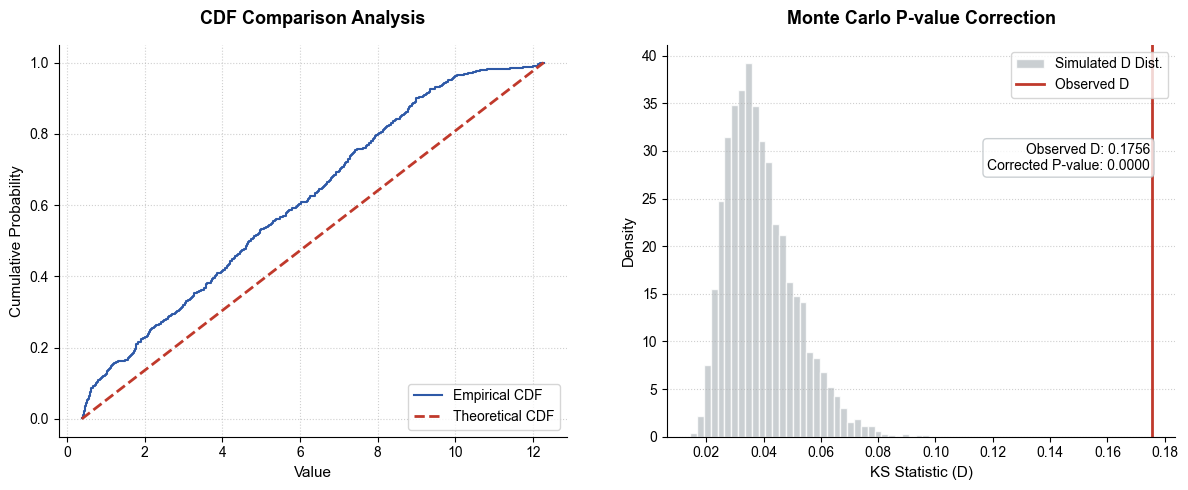

Fit Results: a=0.380, b=12.280
Corrected P-value: 0.0000


In [4]:
# 1. 数据准备
# 假设 df 已经由之前的步骤读入
df_clean = df[df['Trial'] != 'Total'].copy()
person1_data = df_clean['Person3'].astype(float).values
n_samples = len(person1_data)

# 2. 参数估计与 KS 统计量计算
a_obs, scale_obs = uniform.fit(person1_data)
b_obs = a_obs + scale_obs
d_obs, _ = kstest(person1_data, 'uniform', args=(a_obs, scale_obs))

# 3. 蒙特卡洛模拟 (5000次)
n_sims = 5000
d_sims = np.zeros(n_sims)

print(f"Executing Monte Carlo Simulation ({n_sims} iterations)...")
for i in range(n_sims):
    sim_sample = uniform.rvs(loc=a_obs, scale=scale_obs, size=n_samples)
    a_sim, scale_sim = uniform.fit(sim_sample)
    d_sim, _ = kstest(sim_sample, 'uniform', args=(a_sim, scale_sim))
    d_sims[i] = d_sim

p_corrected = np.mean(d_sims >= d_obs)

# 4. 绘图 (优化比例与外观)
# 设置全局样式
plt.rcParams['font.sans-serif'] = ['Arial'] 
plt.rcParams['axes.unicode_minus'] = False

# 调整画布比例为 12:5，增加 dpi 使图像更清晰
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

# --- Left Plot: ECDF vs Theoretical CDF ---
sorted_data = np.sort(person1_data)
ecdf = np.arange(1, n_samples + 1) / n_samples
x_range = np.linspace(a_obs, b_obs, 200)
theoretical_cdf = uniform.cdf(x_range, loc=a_obs, scale=scale_obs)

ax1.step(sorted_data, ecdf, label='Empirical CDF', color='#2E59A7', lw=1.5, where='post', zorder=2)
ax1.plot(x_range, theoretical_cdf, label='Theoretical CDF', color='#C0392B', linestyle='--', lw=2, zorder=3)

ax1.set_title('CDF Comparison Analysis', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Value', fontsize=11)
ax1.set_ylabel('Cumulative Probability', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(frameon=True, loc='lower right')
# 去掉上方和右方线条，更美观
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Right Plot: Monte Carlo Distribution of D ---
# 使用稍微透明的条形，并调整颜色
ax2.hist(d_sims, bins=35, color='#BDC3C7', edgecolor='white', alpha=0.8, density=True, label='Simulated D Dist.')
ax2.axvline(d_obs, color='#C0392B', linestyle='-', linewidth=2, label=f'Observed D')

# 动态标注 P 值
ax2.set_title('Monte Carlo P-value Correction', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('KS Statistic (D)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6, axis='y')

# 优化标注文本的位置和样式
text_str = f'Observed D: {d_obs:.4f}\nCorrected P-value: {p_corrected:.4f}'
ax2.text(0.95, 0.75, text_str, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#BDC3C7'))

ax2.legend(loc='upper right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 调整子图间的距离，防止标签重叠
plt.tight_layout(w_pad=4.0)
plt.show()

# 控制台输出
print(f"Fit Results: a={a_obs:.3f}, b={b_obs:.3f}")
print(f"Corrected P-value: {p_corrected:.4f}")

##### 2.1.4 结论
$X_1$服从均匀分布，$X_i$(i>1)不服从均匀分布

#### 2.2 猜测模型二：正态分布

##### 2.2.1 模型描述

考虑到样本直方图尾部的递减形状和正态分布相似，以及正态分布的普遍性，我们再尝试用正态分布。

##### 2.2.2 数据拟合&检验

Executing Monte Carlo Simulation for Person3...


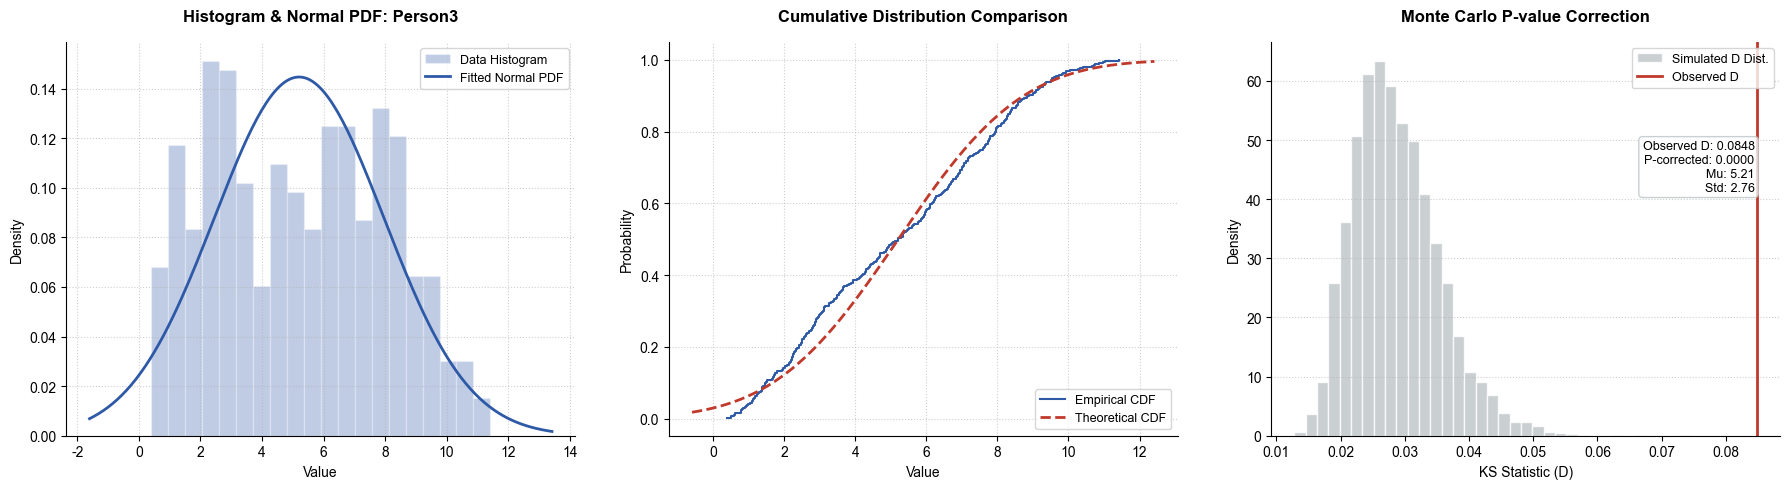

Results for Person3:
Normal Parameters: Mu=5.208, Std=2.758
KS Statistic D:    0.0848
Corrected P-value: 0.0000


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, kstest
import io
df = pd.read_csv('envelopes.csv')
# 1. 数据准备
# 剔除最后一行 "Total"
df_clean = df[df['Trial'] != 'Total'].copy()

# 选择目标数据（这里以 Person1 为例）
target_person = 'Person3' 
data_values = df_clean[target_person].astype(float).values
n_samples = len(data_values)

# 2. 参数估计与 KS 统计量计算
mu_obs, std_obs = norm.fit(data_values)
d_obs, _ = kstest(data_values, 'norm', args=(mu_obs, std_obs))

# 3. 蒙特卡洛模拟 (5000次)
n_sims = 5000
d_sims = np.zeros(n_sims)

print(f"Executing Monte Carlo Simulation for {target_person}...")
for i in range(n_sims):
    sim_sample = norm.rvs(loc=mu_obs, scale=std_obs, size=n_samples)
    mu_sim, std_sim = norm.fit(sim_sample)
    d_sim, _ = kstest(sim_sample, 'norm', args=(mu_sim, std_sim))
    d_sims[i] = d_sim

p_corrected = np.mean(d_sims >= d_obs)

# 4. 绘图 (调整为三子图，比例 18:5)
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

# 增加画布宽度以容纳三个图
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), dpi=100)

# --- Plot 1: Histogram & PDF ---
# 绘制直方图 (使用较淡的蓝色)
ax1.hist(data_values, bins=20, density=True, color='#2E59A7', alpha=0.3, edgecolor='white', label='Data Histogram')
# 绘制 PDF 曲线 (使用深蓝色)
x_pdf = np.linspace(data_values.min() - 2, data_values.max() + 2, 200)
y_pdf = norm.pdf(x_pdf, mu_obs, std_obs)
ax1.plot(x_pdf, y_pdf, color='#2E59A7', lw=2, label='Fitted Normal PDF')

ax1.set_title(f'Histogram & Normal PDF: {target_person}', fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Value', fontsize=10)
ax1.set_ylabel('Density', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Plot 2: ECDF vs Normal CDF (配色保持一致) ---
sorted_data = np.sort(data_values)
ecdf = np.arange(1, n_samples + 1) / n_samples
x_cdf = np.linspace(sorted_data.min() - 1, sorted_data.max() + 1, 200)
y_cdf = norm.cdf(x_cdf, loc=mu_obs, scale=std_obs)

ax2.step(sorted_data, ecdf, label='Empirical CDF', color='#2E59A7', lw=1.5, where='post')
ax2.plot(x_cdf, y_cdf, label='Theoretical CDF', color='#C0392B', linestyle='--', lw=2)

ax2.set_title('Cumulative Distribution Comparison', fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel('Value', fontsize=10)
ax2.set_ylabel('Probability', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower right', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- Plot 3: D-statistic Rank Analysis (配色保持一致) ---
ax3.hist(d_sims, bins=35, color='#BDC3C7', edgecolor='white', alpha=0.8, density=True, label='Simulated D Dist.')
ax3.axvline(d_obs, color='#C0392B', linestyle='-', linewidth=2, label='Observed D')

ax3.set_title('Monte Carlo P-value Correction', fontsize=12, fontweight='bold', pad=15)
ax3.set_xlabel('KS Statistic (D)', fontsize=10)
ax3.set_ylabel('Density', fontsize=10)
ax3.grid(True, linestyle=':', alpha=0.6, axis='y')

# 标注信息框
text_str = f'Observed D: {d_obs:.4f}\nP-corrected: {p_corrected:.4f}\nMu: {mu_obs:.2f}\nStd: {std_obs:.2f}'
ax3.text(0.95, 0.75, text_str, transform=ax3.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#BDC3C7'))

ax3.legend(loc='upper right', fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout(w_pad=3.0)
plt.show()

# 控制台结果
print(f"Results for {target_person}:")
print(f"Normal Parameters: Mu={mu_obs:.3f}, Std={std_obs:.3f}")
print(f"KS Statistic D:    {d_obs:.4f}")
print(f"Corrected P-value: {p_corrected:.4f}")

##### 2.2.3 结论
可以发现P值依旧很小，说明数据并不符合正态分布

#### 2.3 模型猜测三：分段式模型

##### 2.3.1 模型描述

尝试了其他几种模型后，发现其表现都不尽如人意，考虑到直方图中表现出的头部快速下降，后平稳再下降的趋势，我们决定使用分段混合式模型:
模型由三段组成，第一段为指数衰减段，第二段为均匀分布段，第三段为指数衰减段，具体解析式和参数表示见下：

##### 1. 概率密度函数 $f(x)$

$$
f(x|\theta) = 
\begin{cases} 
k \cdot e^{\lambda_1(\tau_1 - x)} & a \le x < \tau_1 & \text{(第一段：指数衰减)} \\
k & \tau_1 \le x \le \tau_2 & \text{(第二段：均匀平台)} \\
k \cdot e^{-\lambda_2(x - \tau_2)} & \tau_2 < x \le b & \text{(第三段：指数衰减)} \\
0 & \text{其他}
\end{cases}
$$

其中，$k$ 是**归一化常数**（即平台高度），由全概率公理 $\int_a^b f(x)dx = 1$ 确定。

##### 2. 归一化常数 $k$ 的推导

计算三个分段区域的面积：
- **Area 1**: $\int_a^{\tau_1} k e^{\lambda_1(\tau_1 - x)} dx = k \left[ \frac{e^{\lambda_1(\tau_1 - a)} - 1}{\lambda_1} \right]$
- **Area 2**: $\int_{\tau_1}^{\tau_2} k dx = k(\tau_2 - \tau_1)$
- **Area 3**: $\int_{\tau_2}^b k e^{-\lambda_2(x - \tau_2)} dx = k \left[ \frac{1 - e^{-\lambda_2(b - \tau_2)}}{\lambda_2} \right]$

令总面积等于 1，解得 $k$：
$$k = \left[ \frac{e^{\lambda_1(\tau_1 - a)} - 1}{\lambda_1} + (\tau_2 - \tau_1) + \frac{1 - e^{-\lambda_2(b - \tau_2)}}{\lambda_2} \right]^{-1}$$

##### 3. 累积分布函数 $F(x)$

$$
F(x) = 
\begin{cases} 
k \frac{e^{\lambda_1(\tau_1 - a)} - e^{\lambda_1(\tau_1 - x)}}{\lambda_1} & a \le x < \tau_1 \\
F(\tau_1) + k(x - \tau_1) & \tau_1 \le x \le \tau_2 \\
F(\tau_2) + k \frac{1 - e^{-\lambda_2(x - \tau_2)}}{\lambda_2} & \tau_2 < x \le b
\end{cases}
$$



模型包含以下 4 个待估参数（假设边界 $a, b$ 已知）：

1.  **$\tau_1$ (第一转折点)**：数据从初始衰减进入稳定平台的临界值。
2.  **$\tau_2$ (第二转折点)**：数据从稳定平台进入末端衰减的临界值。要求 $a < \tau_1 < \tau_2 < b$。
3.  **$\lambda_1$ (起始衰减率)**：控制首段下降的陡峭程度。$\lambda_1 > 0$ 时，曲线从左向右下降。
4.  **$\lambda_2$ (末端衰减率)**：控制尾段下降的陡峭程度。$\lambda_2 > 0$ 时，曲线从平台向右下降。

##### 2.3.2 最大似然估计 (MLE) 求解

给定一组独立同分布（i.i.d.）的观测样本 $x = \{x_1, x_2, ..., x_n\}$。

##### 1. 构建似然函数 $L(\theta)$

$$L(\theta) = \prod_{i=1}^{n} f(x_i | \tau_1, \tau_2, \lambda_1, \lambda_2)$$

##### 2. 构建对数似然函数 $\ell(\theta)$

为了简化计算，取对数：
$$\ell(\theta) = \sum_{i=1}^{n} \ln f(x_i)$$

根据 $x_i$ 落在的不同区间进行分类计数：
- 令 $n_1, n_2, n_3$ 分别为落在三个区间的样本数量。
- 展开对数项：
$$\ell(\theta) = n \ln k + \sum_{x_i \in [a, \tau_1)} \lambda_1(\tau_1 - x_i) + \sum_{x_i \in (\tau_2, b]} -\lambda_2(x_i - \tau_2)$$

其中 $k$ 是关于所有 4 个参数的复杂函数。

##### 3. 求解导数（一阶条件）

理论上，我们需要对各参数求偏导并令其为 0：
- $\frac{\partial \ell}{\partial \lambda_1} = 0, \quad \frac{\partial \ell}{\partial \lambda_2} = 0$
- $\frac{\partial \ell}{\partial \tau_1} = 0, \quad \frac{\partial \ell}{\partial \tau_2} = 0$

**注意**：由于 $k$ 的表达式包含指数项且分段点 $\tau$ 出现在求和符号的指示函数中，该方程组没有解析解（Closed-form solution）。

##### 4. 数值优化算法过程

在实际计算中，我们用 `L-BFGS-B` 算法来最大化 $\ell(\theta)$：

1.  **约束条件**：
    *   $a + \epsilon \le \tau_1 \le \tau_2 - \epsilon$
    *   $\tau_1 + \epsilon \le \tau_2 \le b - \epsilon$
    *   $\lambda_1, \lambda_2 > 0$
2.  **目标函数**：最小化负对数似然函数 $-\ell(\theta)$。
3.  **搜索过程**：
    *   算法在四维空间搜索 $(\tau_1, \tau_2, \lambda_1, \lambda_2)$。
    *   每一轮迭代都会根据当前的参数重新计算归一化系数 $k$。
    *   利用梯度下降或拟牛顿法寻找使样本出现概率最大的参数组合。

##### 2.3.3 数据拟合&模型检验

Running Analysis for Person1...


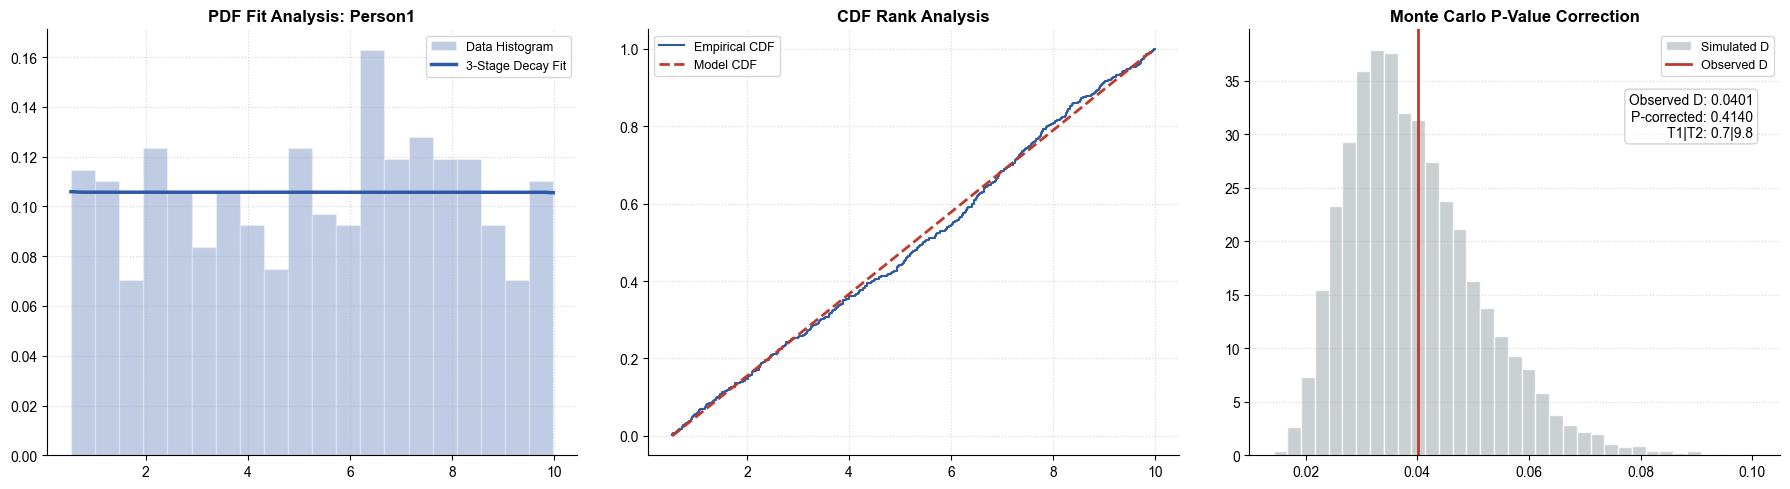

Analysis for Person1 completed. P-corrected: 0.4140


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import kstest
import io
df = pd.read_csv('envelopes.csv')
def analyze_person_distribution(person_num):
    """
    全过程分析函数：拟合三段式(衰减-平台-衰减)分布并进行蒙特卡洛P值修正
    参数 person_num: 整数，对应 Person1, Person2...
    """
    # --- 1. 数据提取与预处理 ---
    target_col = f'Person{person_num}'
    # 假设 df 已经在全局作用域中定义
    df_clean = df[df['Trial'] != 'Total'].copy()
    data = df_clean[target_col].astype(float).values
    n_samples = len(data)
    v_min, v_max = data.min(), data.max()

    # --- 2. 模型核心数学定义 ---
    def get_params(t1, t2, l1, l2, a, b):
        area1 = (np.exp(l1 * (t1 - a)) - 1) / max(l1, 1e-10)
        area2 = t2 - t1
        area3 = (1 - np.exp(-l2 * (b - t2))) / max(l2, 1e-10)
        k = 1.0 / (area1 + area2 + area3)
        p1 = k * area1
        p2 = p1 + k * area2
        return k, p1, p2

    def pdf_func(x, t1, t2, l1, l2, a, b):
        k, _, _ = get_params(t1, t2, l1, l2, a, b)
        pdf = np.zeros_like(x)
        m1, m2, m3 = (x < t1), (x >= t1) & (x <= t2), (x > t2)
        pdf[m1] = k * np.exp(l1 * (t1 - x[m1]))
        pdf[m2] = k
        pdf[m3] = k * np.exp(-l2 * (x[m3] - t2))
        return pdf

    def cdf_func(x, t1, t2, l1, l2, a, b):
        k, p1, p2 = get_params(t1, t2, l1, l2, a, b)
        cdf = np.zeros_like(x)
        m1 = (x >= a) & (x < t1)
        cdf[m1] = k * (np.exp(l1 * (t1 - a)) - np.exp(l1 * (t1 - x[m1]))) / max(l1, 1e-10)
        m2 = (x >= t1) & (x <= t2)
        cdf[m2] = p1 + k * (x[m2] - t1)
        m3 = (x > t2) & (x <= b)
        cdf[m3] = p2 + k * (1 - np.exp(-l2 * (x[m3] - t2))) / max(l2, 1e-10)
        cdf[x > b] = 1.0
        return np.clip(cdf, 0, 1)

    def rvs_func(size, t1, t2, l1, l2, a, b):
        k, p1, p2 = get_params(t1, t2, l1, l2, a, b)
        u = np.random.random(size)
        res = np.zeros(size)
        i1, i2, i3 = (u < p1), (u >= p1) & (u < p2), (u >= p2)
        res[i1] = t1 - np.log(np.exp(l1 * (t1 - a)) - u[i1] * l1 / k) / max(l1, 1e-10)
        res[i2] = t1 + (u[i2] - p1) / k
        res[i3] = t2 - np.log(1 - (u[i3] - p2) * l2 / k) / max(l2, 1e-10)
        return np.clip(res, a, b)

    # --- 3. 拟合与蒙特卡洛模拟 ---
    def nll(p, obs):
        t1, t2, l1, l2 = p
        if t1 >= t2 or t1 <= v_min or t2 >= v_max or l1 <= 0 or l2 <= 0: return 1e12
        return -np.sum(np.log(pdf_func(obs, t1, t2, l1, l2, v_min, v_max) + 1e-12))

    # 初始拟合
    bnds = [(v_min+0.2, v_max-0.2), (v_min+0.2, v_max-0.2), (0.01, 5), (0.01, 5)]
    res_obs = minimize(nll, x0=[v_min+1, v_max-1, 0.5, 0.5], args=(data,), bounds=bnds)
    t1_o, t2_o, l1_o, l2_o = res_obs.x
    
    # 观测到的 D 统计量
    d_obs = kstest(data, lambda x: cdf_func(x, t1_o, t2_o, l1_o, l2_o, v_min, v_max)).statistic

    # 蒙特卡洛 5000 次
    n_sims = 5000
    d_sims = []
    print(f"Running Analysis for {target_col}...")
    for _ in range(n_sims):
        s_data = rvs_func(n_samples, t1_o, t2_o, l1_o, l2_o, v_min, v_max)
        # 快速拟合获取模拟 D 值
        s_res = minimize(nll, x0=[t1_o, t2_o, l1_o, l2_o], args=(s_data,), bounds=bnds, tol=1e-1)
        d_sims.append(kstest(s_data, lambda x: cdf_func(x, *s_res.x, v_min, v_max)).statistic)

    p_corrected = np.mean(np.array(d_sims) >= d_obs)

    # --- 4. 绘图 (比例 18:5) ---
    plt.rcParams['font.sans-serif'] = ['Arial']
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), dpi=100)
    x_grid = np.linspace(v_min, v_max, 500)

    # Ax1: Histogram & PDF
    ax1.hist(data, bins=20, density=True, color='#2E59A7', alpha=0.3, edgecolor='white', label='Data Histogram')
    ax1.plot(x_grid, pdf_func(x_grid, t1_o, t2_o, l1_o, l2_o, v_min, v_max), color='#2E59A7', lw=2.5, label='3-Stage Decay Fit')
    ax1.set_title(f'PDF Fit Analysis: {target_col}', fontweight='bold')
    ax1.legend(fontsize=9); ax1.grid(True, linestyle=':', alpha=0.5); ax1.spines[['top','right']].set_visible(False)

    # Ax2: CDF Comparison
    ax2.step(np.sort(data), np.arange(1, n_samples+1)/n_samples, label='Empirical CDF', color='#2E59A7', lw=1.5)
    ax2.plot(x_grid, cdf_func(x_grid, t1_o, t2_o, l1_o, l2_o, v_min, v_max), label='Model CDF', color='#C0392B', ls='--', lw=2)
    ax2.set_title('CDF Rank Analysis', fontweight='bold')
    ax2.legend(fontsize=9); ax2.grid(True, linestyle=':', alpha=0.5); ax2.spines[['top','right']].set_visible(False)

    # Ax3: MC Rank
    ax3.hist(d_sims, bins=35, color='#BDC3C7', edgecolor='white', alpha=0.8, density=True, label='Simulated D')
    ax3.axvline(d_obs, color='#C0392B', lw=2, label='Observed D')
    ax3.set_title('Monte Carlo P-Value Correction', fontweight='bold')
    info = f'Observed D: {d_obs:.4f}\nP-corrected: {p_corrected:.4f}\nT1|T2: {t1_o:.1f}|{t2_o:.1f}'
    ax3.text(0.95, 0.85, info, transform=ax3.transAxes, ha='right', va='top', bbox=dict(boxstyle='round', fc='white', alpha=0.7, ec='#BDC3C7'))
    ax3.legend(fontsize=9); ax3.grid(True, linestyle=':', alpha=0.5, axis='y'); ax3.spines[['top','right']].set_visible(False)

    plt.tight_layout(w_pad=3.0)
    plt.show()
    
    print(f"Analysis for {target_col} completed. P-corrected: {p_corrected:.4f}")

# 分析第一个人
analyze_person_distribution(1)

Running Analysis for Person2...


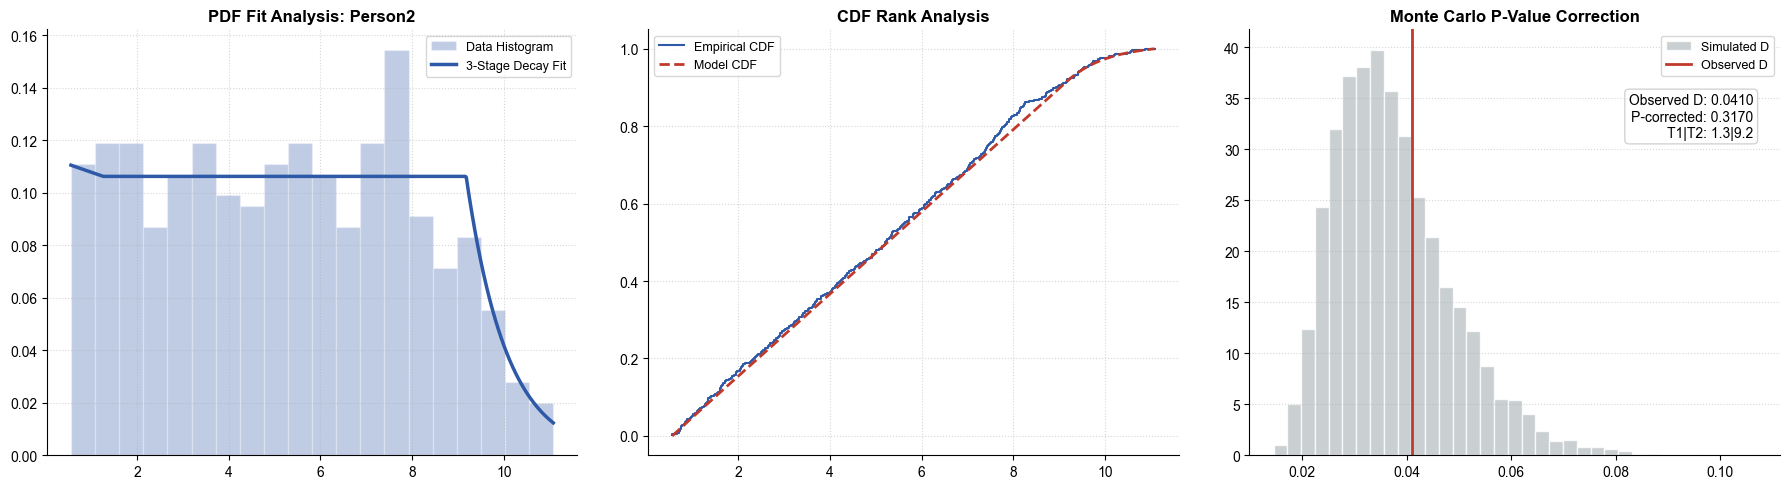

Analysis for Person2 completed. P-corrected: 0.3170


In [7]:
analyze_person_distribution(2)

Running Analysis for Person3...


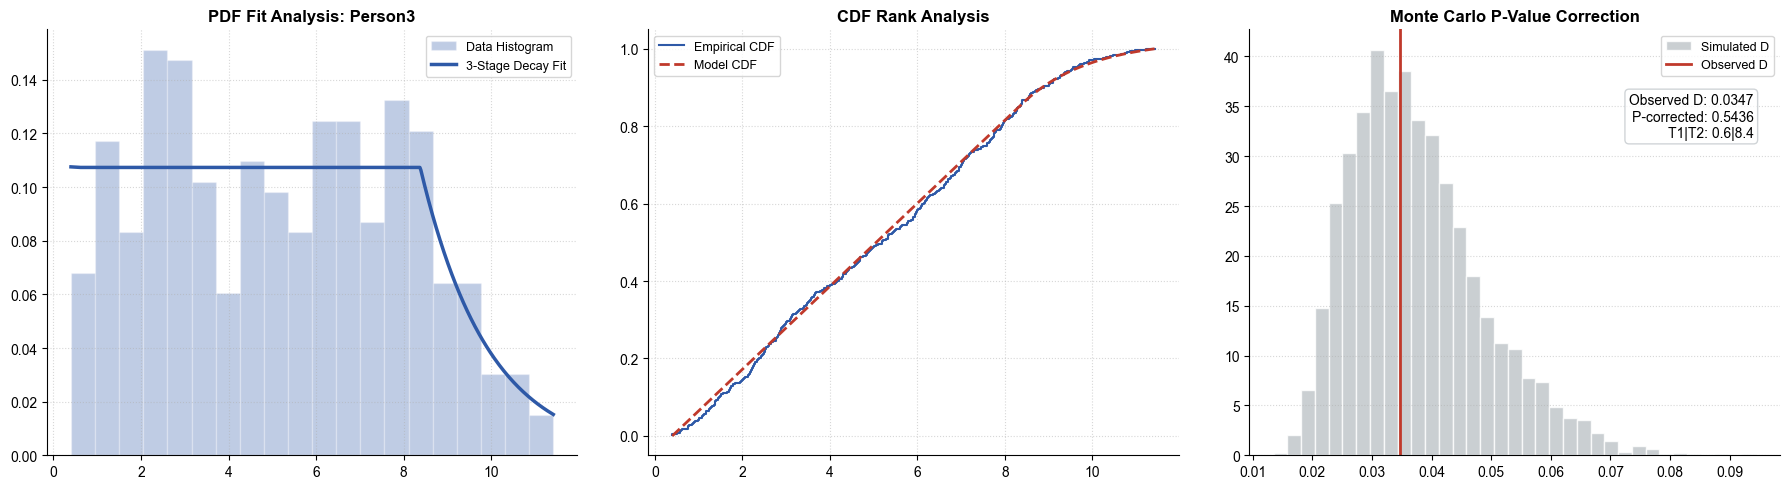

Analysis for Person3 completed. P-corrected: 0.5436


In [8]:
analyze_person_distribution(3)

Running Analysis for Person4...


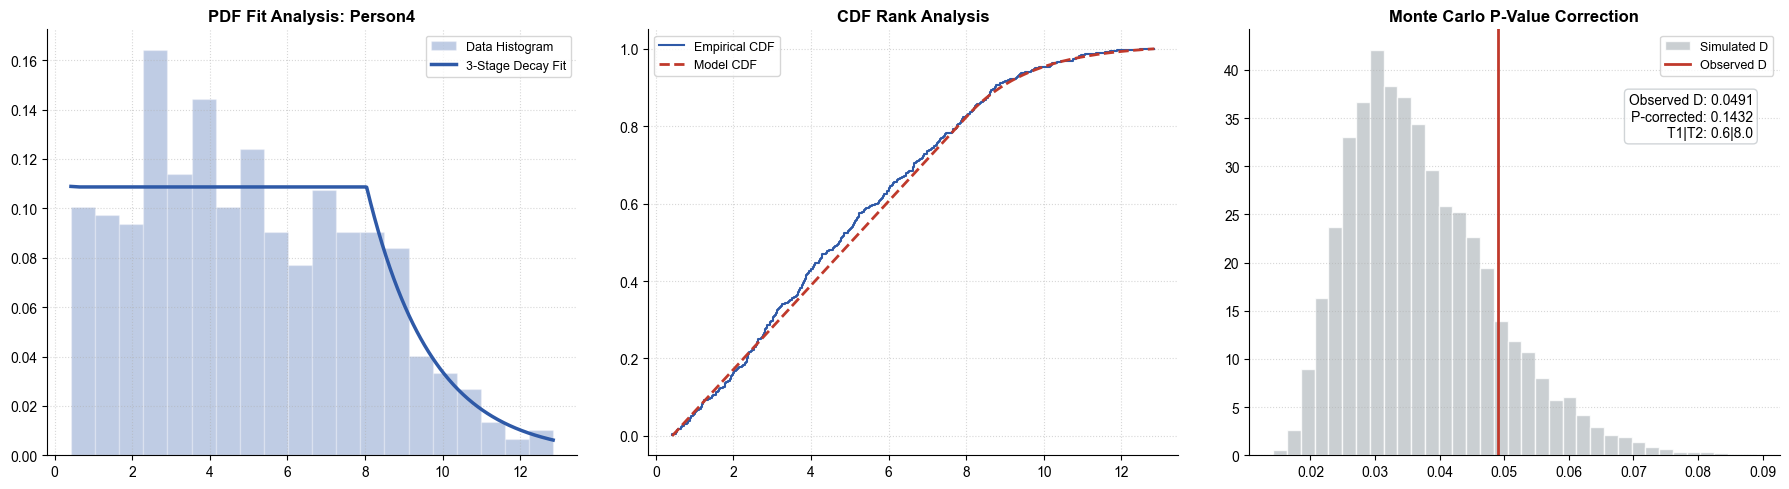

Analysis for Person4 completed. P-corrected: 0.1432


In [9]:
analyze_person_distribution(4)

Running Analysis for Person5...


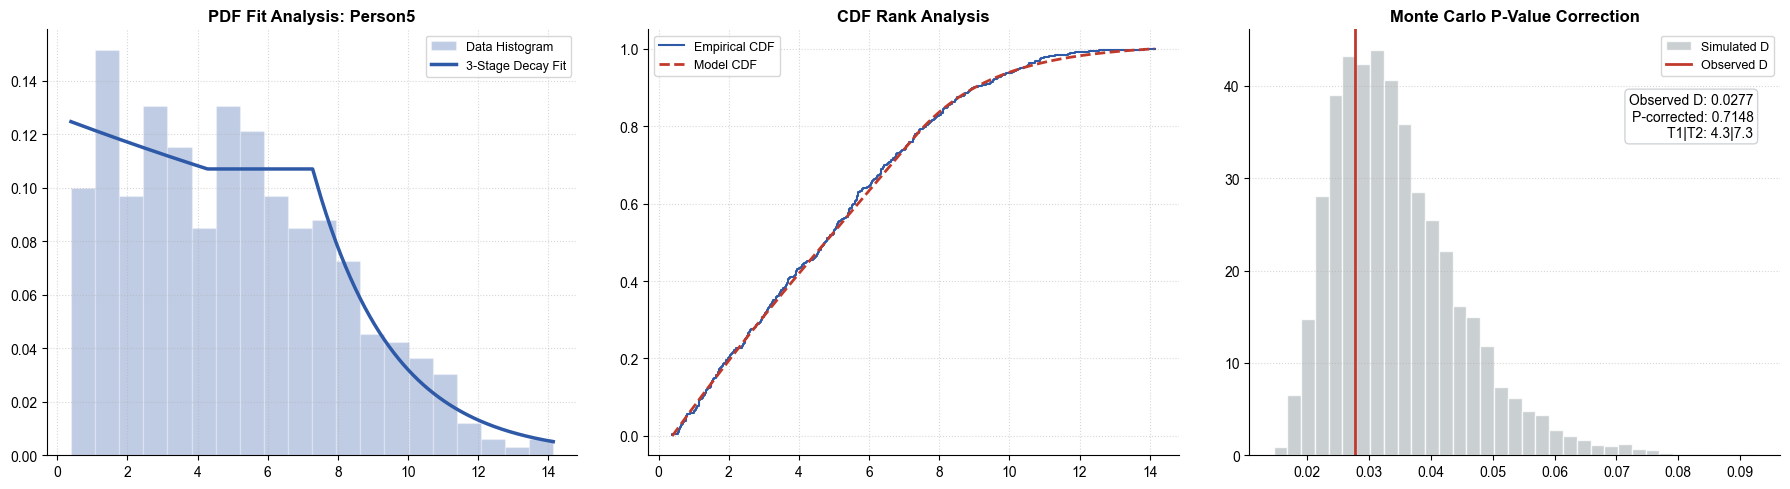

Analysis for Person5 completed. P-corrected: 0.7148


In [10]:
analyze_person_distribution(5)

Running Analysis for Person6...


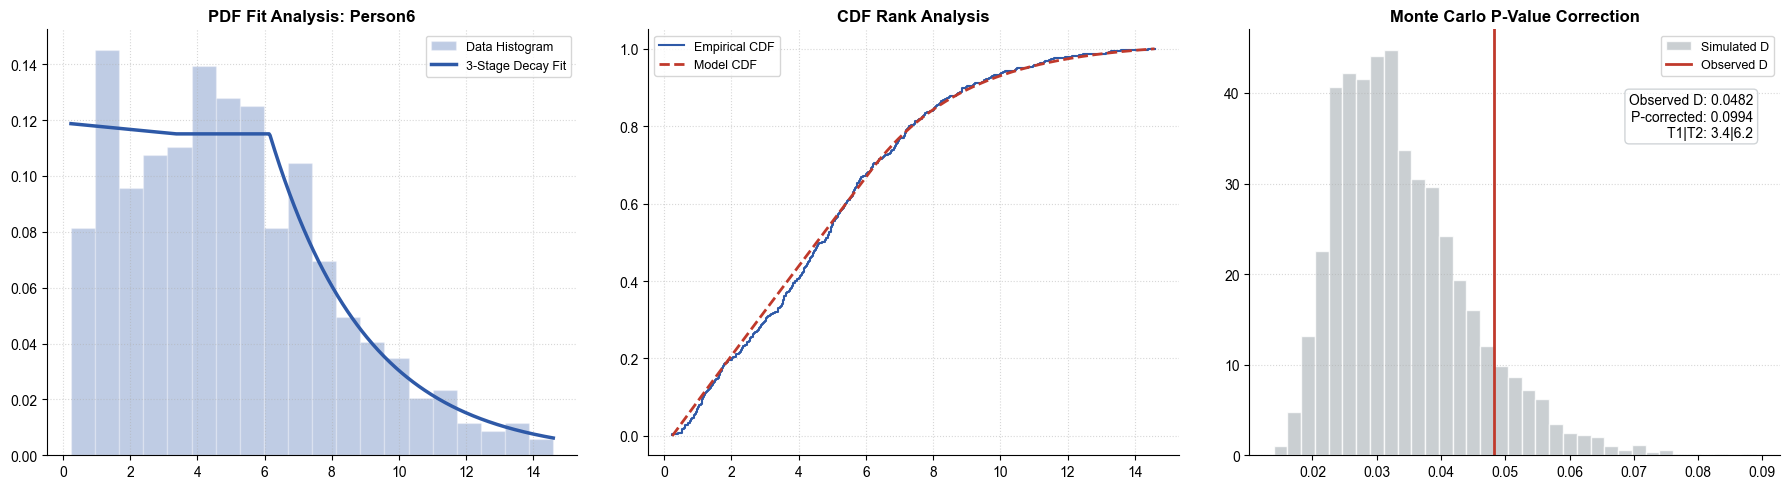

Analysis for Person6 completed. P-corrected: 0.0994


In [11]:
analyze_person_distribution(6)

Running Analysis for Person7...


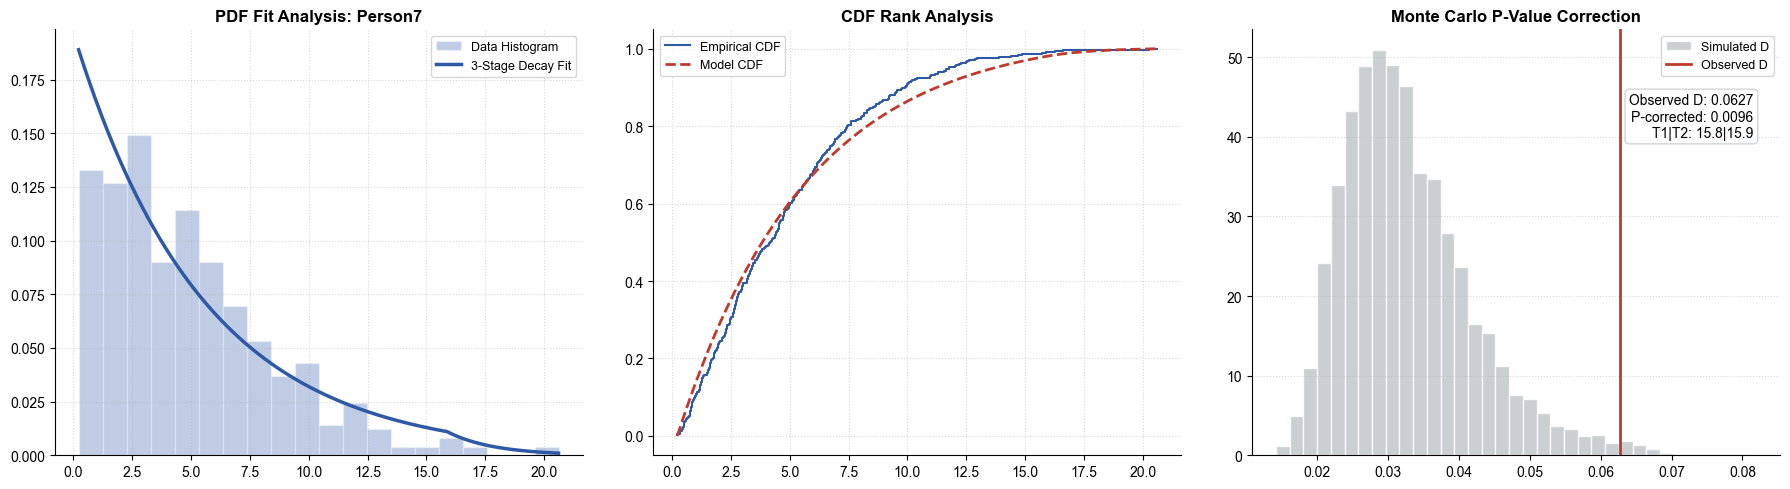

Analysis for Person7 completed. P-corrected: 0.0096


In [12]:
analyze_person_distribution(7)

Running Analysis for Person8...


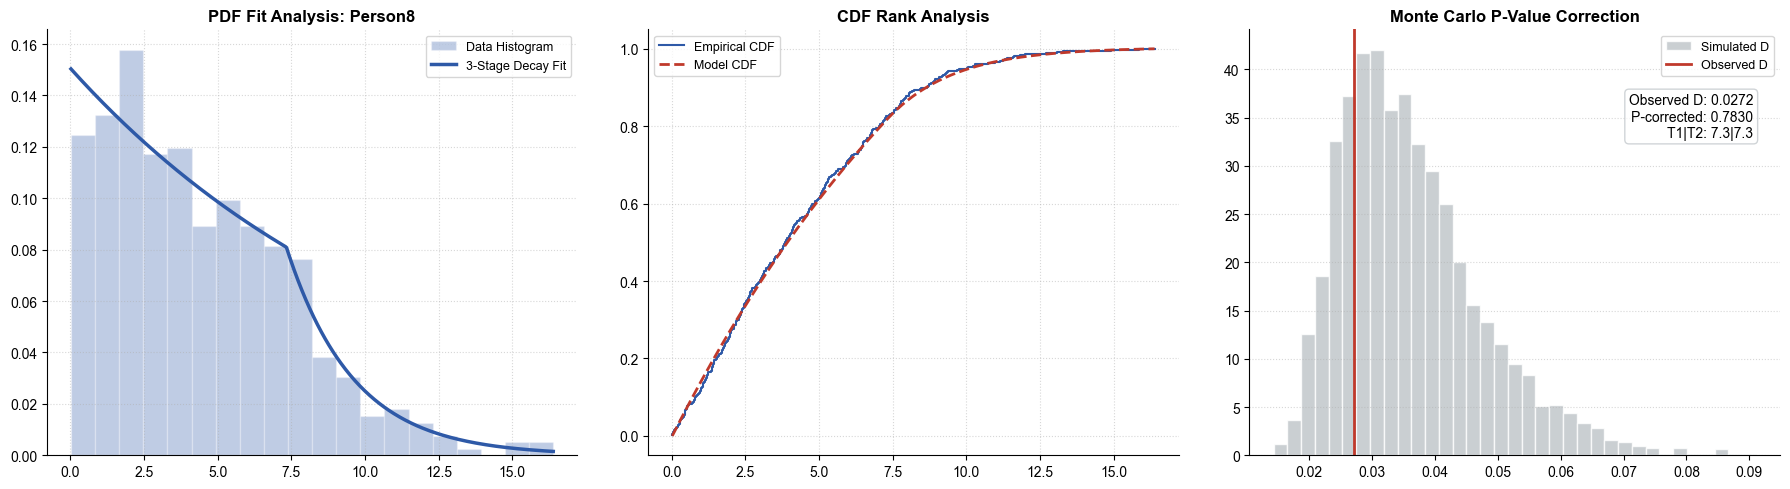

Analysis for Person8 completed. P-corrected: 0.7830


In [13]:
analyze_person_distribution(8)

##### 2.3.4 结论
由P值可知这个三段模型对于X_i(1< i < 7)的拟合效果是非常好的。当i变大时，均匀分布的区间退化为0，整个X_i分布退化为近似于指数分布，但最后一个人的分布不能用三段式模型拟合。

然而这不能说明三段模型的错误，$X_n$的偏差是由于自由度的丧失导致的。由于总金额固定，最后一人的金额 $X_8 = S - \sum_{i=1}^{7} X_i$。这意味着 Person 8 **完全没有自主的分布规律**。他不是被某种“分配逻辑”产生的，而是被前 7 个人“挤”出来的剩余物。在统计学上，他的自由度为 0。

#### 3.